## Propagating in a custom basis: the qudit Weyl–Heisenberg group

propaq's propagation engine is not built around a specific algebra, it's designed to be generic.
We implement Pauli and Majorana propagation as examples, but this notebook demonstrates how to implement
your own basis and propagate in it.

This notebook adds the generalized Weyl–Heisenberg basis
for $n$ qudits of local dimension $d$, the clock/shift algebra that replaces the Pauli
group when your degrees of freedom have more than two levels. We build it against propaq's
own abstract interfaces, and verify its correctness by checking that it reproduces known results:

1. **the algebra** reproduces dense matrix products exactly, for $d = 2\ldots7$
2. **the branching rule** reproduces dense Heisenberg conjugation $U^\dagger W U$ exactly
3. on the $\mathbb{Z}_d$ **quantum clock (Potts) model** it matches an exact $d^n \times d^n$
   dense simulation, and it matches a **closed-form analytic solution** for the decoupled limit
4. at $d = 2$ the whole construction collapses onto ordinary Pauli propagation, and we check
   it against propaq's `PauliPropagator`.

### NOTE: As of version 0.1.5, the abstract propagation engine does not exploit the multithreaded Rust backend. This is primarily due to challenges in Python-Rust interop in the hot loop of the propagation engine. We are actively developing methods to allow custom bases to take advantage of the Rust backend. 

### Required implementations

We detail the abstract methods that a term class must implement to be used in the propagation engine.
Both ask for:

| What the engine needs | `AbstractTerm` method | Pauli | Weyl (this notebook) |
| --- | --- | --- | --- |
| Product of two basis elements, with its phase | `__matmul__` | XOR the $x,z$ bitmasks, phase $i^k$ | add exponent vectors mod $d$, phase $\tau^k$ |
| Does a term branch under generator $g$? | (used inside `apply_gate`) | symplectic form mod $2$ | symplectic form mod $d$ |
| Operator weight, for truncation | `weight` | non-identity sites | non-identity sites |
| Diagonal expectation against a basis state | `trace_with_fock_state` | $\pm 1$ when $X$-free | $\omega^{\,b\cdot f}$ when $X$-free |
| Per-gate cached data | (built by the rotation itself) | the generator | powers $W_g^{\,j}$ and a $d \times d$ branch table |

Once a term implements `AbstractTerm`, the propagator needs `apply_gate(term, coeff, rotation)`, the per-gate branching rule. Everything else is inherited from the abstraction.

In [1]:

import cmath
import math
import time
from dataclasses import dataclass
from functools import lru_cache

import matplotlib.pyplot as plt; plt.rcParams.update({"font.family": "serif", "font.size": 12})
import numpy as np
from scipy.linalg import expm

from propaq.datatypes import DictTermSum
from propaq.datatypes.abstract import AbstractTerm
from propaq.noise import UniformNoiseModel
from propaq.propagators import AbstractPropagator
from propaq.truncation import CoefficientTruncator, WeightTruncator

## 1. The algebra

On one qudit of dimension $d$, the **shift** and **clock** operators are

$$X\,|j\rangle = |j+1 \bmod d\rangle, \qquad Z\,|j\rangle = \omega^{\,j}\,|j\rangle, \qquad \omega = e^{2\pi i/d},$$

which obey $X^d = Z^d = \mathbb{1}$ and the defining relation $ZX = \omega\, XZ$. For $d = 2$
these are exactly $\sigma^x$ and $\sigma^z$.

A **Weyl string** on $n$ qudits is labelled by two exponent vectors $a, b \in \mathbb{Z}_d^n$:

$$W(a,b) \;=\; \tau^{\,a\cdot b}\; X^{a}Z^{b}, \qquad X^a Z^b := \bigotimes_{k} X^{a_k} Z^{b_k}.$$

The prefactor $\tau$ is a square root of $\omega$. We take

$$\tau = \begin{cases} e^{i\pi/d} & d \text{ even} \\ \omega^{(d+1)/2} = e^{i\pi(d+1)/d} & d \text{ odd,}\end{cases}$$

which is the standard Weyl convention for odd $d$. This implies $W(v)^\dagger = W(v)^{-1}$ lands back on the label $-v$, and $W(v)^d = \mathbb{1}$ for
*every* $v$. Therefore, each $W_v$ has spectrum exactly $\{\omega^k\}$. It also makes $d = 2$ agree
with propaq's Pauli phase convention: $\tau = i$, so $W(1,1) = i\,XZ = Y$.

Computing products of two Weyl strings can be done as follows -

$$W(v)\,W(u) \;=\; \tau^{\,E(v,u)}\; W\big(\bar{s},\bar{t}\big), \qquad
\begin{aligned} \bar{s} &= v_a + u_a \bmod d \\ \bar{t} &= v_b + u_b \bmod d \end{aligned}$$

$$E(v,u) \;=\; v_a\!\cdot\!v_b \;+\; u_a\!\cdot\!u_b \;+\; 2\,u_a\!\cdot\!v_b \;-\; \bar{s}\cdot\bar{t} \pmod{2d}.$$

Since $E(v,u) - E(u,v) = 2(u_a\!\cdot\!v_b - v_a\!\cdot\!u_b)$ and $\tau^2 = \omega$, the commutation relations are given by 

$$W(u)\,W(v) \;=\; \omega^{\,\sigma(v,u)}\; W(v)\,W(u), \qquad \sigma(v,u) = v_a\!\cdot\!u_b - u_a\!\cdot\!v_b \bmod d.$$

$\sigma$ is the symplectic form over $\mathbb{Z}_d$.

In [2]:
def tau_pow(d: int, e: int) -> complex:
    """$\\tau^e$, with $\\tau^2 = \\omega$ and $W(v)^d = 1$ for every $v$."""
    k = 1 if d % 2 == 0 else d + 1
    return cmath.exp(1j * math.pi * k * (e % (2 * d)) / d)


def omega_pow(d: int, e: int) -> complex:
    """$\\omega^e = e^{2\\pi i e/d}$."""
    return cmath.exp(2j * math.pi * (e % d) / d)


@dataclass(frozen=True, slots=True)
class WeylString(AbstractTerm):
    """$W(a,b) = \\tau^{a\\cdot b} X^a Z^b$ on ``len(a)`` qudits of dimension ``d``."""

    a: tuple[int, ...]  # X exponents, each in [0, d)
    b: tuple[int, ...]  # Z exponents, each in [0, d)
    d: int

    @property
    def n_units(self) -> int:
        return len(self.a)

    @property
    def weight(self) -> int:
        """Sites carrying a non-identity single-qudit operator."""
        return sum(1 for ai, bi in zip(self.a, self.b) if ai or bi)

    def __matmul__(self, other: "WeylString") -> tuple[complex, "WeylString"]:
        """``self @ other``, as a (phase, basis element) pair."""
        d, e, na, nb = self.d, 0, [], []
        for va, vb, ua, ub in zip(self.a, self.b, other.a, other.b):
            s, t = (va + ua) % d, (vb + ub) % d
            e += va * vb + ua * ub + 2 * ua * vb - s * t
            na.append(s)
            nb.append(t)
        return tau_pow(d, e), WeylString(tuple(na), tuple(nb), d)

    def dagger(self) -> tuple[complex, "WeylString"]:
        """$W^\\dagger = W^{-1}$, as a (phase, basis element) pair."""
        inv = WeylString(
            tuple((-x) % self.d for x in self.a), tuple((-x) % self.d for x in self.b), self.d
        )
        phase, _ = self @ inv
        return 1 / phase, inv

    def symplectic(self, other: "WeylString") -> int:
        """$\\sigma$: the $\\mathbb{Z}_d$ generalization of the Pauli anticommutation bit."""
        return sum(
            va * ub - ua * vb for va, vb, ua, ub in zip(self.a, self.b, other.a, other.b)
        ) % self.d

    def commutes_with(self, other: "WeylString") -> bool:
        return self.symplectic(other) == 0

    def trace_with_fock_state(self, fock_state: int | tuple[int, ...]) -> complex:
        """$\\langle f | W | f \\rangle$: zero unless the term is $X$-free.
        """
        if any(self.a):
            return 0j
        if isinstance(fock_state, int):
            fock_state = tuple((fock_state // self.d**k) % self.d for k in range(self.n_units))
        return omega_pow(self.d, sum(bi * fi for bi, fi in zip(self.b, fock_state)))

    def to_bytes(self) -> bytes:
        return bytes(self.a) + bytes(self.b) + bytes([self.d])

    @classmethod
    def from_bytes(cls, data: bytes, n_units: int) -> "WeylString":
        a, b, d = data[:n_units], data[n_units : 2 * n_units], data[-1]
        return cls(tuple(a), tuple(b), d)

    def __hash__(self) -> int:
        return hash((self.a, self.b))

    def __eq__(self, other: object) -> bool:
        return (
            isinstance(other, WeylString) and self.a == other.a and self.b == other.b
        )


def identity(n: int, d: int) -> WeylString:
    return WeylString((0,) * n, (0,) * n, d)


def single(n: int, d: int, k: int, ai: int, bi: int) -> WeylString:
    """$X^{a_i} Z^{b_i}$ acting on site ``k`` alone."""
    a, b = [0] * n, [0] * n
    a[k], b[k] = ai % d, bi % d
    return WeylString(tuple(a), tuple(b), d)

### Algebra implementation against dense matrices
Prior to setting up propagators, we ensure that the algebra we've written is implemented correctly. In order to do this, we can compare to dense matrices.

In [ ]:
def dense(w: WeylString) -> np.ndarray:
    """The explicit $d^n \\times d^n$ matrix of a Weyl string."""
    d = w.d
    X = np.zeros((d, d), complex)
    for j in range(d):
        X[(j + 1) % d, j] = 1.0
    Z = np.diag([np.exp(2j * np.pi * j / d) for j in range(d)])
    out = np.eye(1, dtype=complex)
    for ai, bi in zip(w.a, w.b):
        site = tau_pow(d, ai * bi) * np.linalg.matrix_power(X, ai) @ np.linalg.matrix_power(Z, bi)
        out = np.kron(out, site)
    return out


rng = np.random.default_rng(0)


def random_string(n, d):
    draw = lambda: tuple(int(x) for x in rng.integers(0, d, n))
    return WeylString(draw(), draw(), d)


for d in range(2, 8):
    worst_product = worst_dagger = worst_power = 0.0
    for _ in range(200):
        v, u = random_string(2, d), random_string(2, d)
        phase, prod = v @ u
        worst_product = max(worst_product, np.abs(dense(v) @ dense(u) - phase * dense(prod)).max())
        phase, inv = v.dagger()
        worst_dagger = max(worst_dagger, np.abs(dense(v).conj().T - phase * dense(inv)).mplt())
        worst_power = mplt(worst_power, np.abs(np.linalg.matrix_power(dense(v), d) - np.eye(d**2)).mplt())
    print(
        f"d={d}:  max |W(v)W(u) - phase*W(v+u)| = {worst_product:.2e}"
        f"   |W^dag - phase*W(-v)| = {worst_dagger:.2e}"
        f"   |W^d - 1| = {worst_power:.2e}"
    )

d=2:  max |W(v)W(u) - phase*W(v+u)| = 4.90e-16   |W^dag - phase*W(-v)| = 4.90e-16   |W^d - 1| = 4.90e-16
d=3:  max |W(v)W(u) - phase*W(v+u)| = 7.66e-15   |W^dag - phase*W(-v)| = 7.11e-15   |W^d - 1| = 1.37e-14
d=4:  max |W(v)W(u) - phase*W(v+u)| = 1.73e-15   |W^dag - phase*W(-v)| = 1.83e-15   |W^d - 1| = 4.41e-15
d=5:  max |W(v)W(u) - phase*W(v+u)| = 5.14e-15   |W^dag - phase*W(-v)| = 5.43e-15   |W^d - 1| = 1.69e-14
d=6:  max |W(v)W(u) - phase*W(v+u)| = 6.97e-15   |W^dag - phase*W(-v)| = 6.93e-15   |W^d - 1| = 2.79e-14
d=7:  max |W(v)W(u) - phase*W(v+u)| = 1.61e-14   |W^dag - phase*W(-v)| = 1.39e-14   |W^d - 1| = 7.67e-14


### d=2 matches Pauli propagation

propaq encodes a Pauli string as $i^{x \cdot z} X^x Z^z$, so the two-level Weyl strings should
come out as $\mathbb{1}, X, Z, Y$.

In [4]:
reference = {
    (0, 0): np.eye(2),
    (1, 0): np.array([[0, 1], [1, 0]], complex),
    (0, 1): np.diag([1.0, -1.0]).astype(complex),
    (1, 1): np.array([[0, -1j], [1j, 0]]),
}
for (x, z), want in reference.items():
    got = dense(WeylString((x,), (z,), 2))
    name = {(0, 0): "I", (1, 0): "X", (0, 1): "Z", (1, 1): "Y"}[(x, z)]
    print(f"W(a={x}, b={z}) == {name}:  {np.allclose(got, want)}   (max dev {np.abs(got - want).max():.1e})")

W(a=0, b=0) == I:  True   (max dev 0.0e+00)
W(a=1, b=0) == X:  True   (max dev 0.0e+00)
W(a=0, b=1) == Z:  True   (max dev 1.2e-16)
W(a=1, b=1) == Y:  True   (max dev 1.8e-16)


## 2. The gate and the d-way branch

A Weyl string is not Hermitian in general for $d > 2$. We can use the Hermitian part of a Weyl string as the generator of a unitary gate.

$$H_g \;=\; \tfrac{1}{2}\big(W_g + W_g^\dagger\big), \qquad U_g(\theta) \;=\; e^{-i\frac{\theta}{2} H_g}.$$

At $d = 2$, $W_g^\dagger = W_g$, so $H_g = W_g$ and $U_g(\theta) = e^{-i\theta P/2}$, matching 
our `PauliRotation`. For general $d$ this is the gate the $\mathbb{Z}_d$ clock
model Trotterizes into.

 Because $W_g^d = \mathbb{1}$, the eigenprojectors of
$W_g$ are $\Pi_k = \frac{1}{d}\sum_m \omega^{-km} W_g^m$, and $H_g$ has eigenvalue
$\cos(2\pi k/d)$ on $\Pi_k$. Therefore, we can write the gate as

$$U_g(\theta) \;=\; \sum_{m=0}^{d-1} c_m\, W_g^{\,m}, \qquad
c_m \;=\; \frac{1}{d}\sum_{k=0}^{d-1} e^{-i\frac{\theta}{2}\cos(2\pi k/d)}\; \omega^{-km}.$$

For $d = 2$ this is $c_0 = \cos(\theta/2)$, $c_1 = -i\sin(\theta/2)$, the half-angle pair.

Let $s = \sigma(v, g)$, so $W_g^{\,j} W(v) = \omega^{\,js} W(v)\, W_g^{\,j}$
for every $j$. Then

$$U_g^\dagger\, W(v)\, U_g \;=\; \sum_{m,m'} \bar{c}_{m'} c_m \, W_g^{-m'} W(v) W_g^{m}
\;=\; \sum_{m,m'} \bar{c}_{m'} c_m\, \omega^{-m's}\, W(v)\, W_g^{\,m-m'},$$

and collecting by $j = m - m'$ gives us

$$\boxed{\;U_g(\theta)^\dagger\, W(v)\, U_g(\theta) \;=\; \sum_{j=0}^{d-1} \Lambda_s[j]\; W(v)\,W_g^{\,j},
\qquad \Lambda_s[j] = \sum_{m=0}^{d-1} \bar{c}_m\, c_{m+j}\; \omega^{-ms}. \;}$$

Therefore, a single Weyl string can be mapped to atmost $d$ strings through a gate's action. $\Lambda$ is a $d \times d$ table that depends only on the
gate, and the term contributes only its symplectic form $s$.

This is a generalization of $Z \mapsto \cos\theta\, Z + \sin\theta\, Y$ for arbitrary $d$.

In [5]:
@lru_cache(maxsize=None)
def _gate_coefficients(d: int, theta: float) -> tuple[complex, ...]:
    """$c_m$ such that $U_g(\\theta) = \\sum_m c_m W_g^m$."""
    k = np.arange(d)
    eigs = np.exp(-0.5j * theta * np.cos(2 * np.pi * k / d))
    return tuple(np.sum(eigs * np.exp(-2j * np.pi * k * m / d)) / d for m in range(d))


class WeylRotation:
    """
    A unitary gate generated by the Hermitian component of a Weyl string.
    """

    def __init__(self, generator: WeylString, angle: float):
        d, n = generator.d, generator.n_units
        self.generator, self.angle = generator, angle

        powers = [(1 + 0j, identity(n, d))]
        for _ in range(d - 1):
            phase, key = powers[-1]
            step_phase, step_key = key @ generator
            powers.append((phase * step_phase, step_key))
        phase, key = powers[-1]
        step_phase, step_key = key @ generator
        if step_key != identity(n, d) or abs(phase * step_phase - 1) > 1e-12:
            raise ValueError("generator does not satisfy W^d = 1")
        self.powers = powers

        c = np.asarray(_gate_coefficients(d, angle))
        omega = np.array([[omega_pow(d, -m * s) for m in range(d)] for s in range(d)])

        self.table = np.array(
            [[np.sum(np.conj(c) * np.roll(c, -j) * omega[s]) for j in range(d)] for s in range(d)]
        )

    def dense_unitary(self) -> np.ndarray:
        """Reference implementation: the explicit matrix exponential."""
        W = dense(self.generator)
        return expm(-0.5j * self.angle * (W + W.conj().T) / 2)



def conjugate(key: WeylString, coeff: complex, rot: WeylRotation):
    """Yield the (child, coefficient) pairs of one term under one gate."""
    row = rot.table[key.symplectic(rot.generator)]
    for j in range(key.d):
        weight = row[j]
        if weight == 0:
            continue
        power_phase, power_key = rot.powers[j]
        phase, child = key @ power_key
        yield child, coeff * weight * power_phase * phase

### The branch rule against dense conjugation

This tests the boxed formula by evaluating it against a brute-force dense conjugation $U^\dagger W(v) U$ using `expm`.

In [6]:
for d in range(2, 6):
    worst = 0.0
    for _ in range(40):
        rot = WeylRotation(random_string(2, d), float(rng.uniform(-3, 3)))
        key = random_string(2, d)
        got = sum(c * dense(child) for child, c in conjugate(key, 1 + 0j, rot))
        U = rot.dense_unitary()
        worst = max(worst, np.abs(got - U.conj().T @ dense(key) @ U).max())
    print(f"d={d}:  max |branch expansion - U^dag W U| = {worst:.2e}   ({d} children per term)")

d=2:  max |branch expansion - U^dag W U| = 7.22e-16   (2 children per term)
d=3:  max |branch expansion - U^dag W U| = 4.45e-15   (3 children per term)
d=4:  max |branch expansion - U^dag W U| = 9.25e-16   (4 children per term)
d=5:  max |branch expansion - U^dag W U| = 3.05e-15   (5 children per term)


## 3. The term sum and the propagator

We can now implement the term sum and propagator. We specify a `term_type` so that we can parse term sums from file, and define the `apply_gate` method to implement the branching rule.

In [7]:
class WeylTermSum(DictTermSum[WeylString]):
    """A linear combination of Weyl strings with complex coefficients."""

    term_type = WeylString


class WeylPropagator(AbstractPropagator[WeylString, WeylRotation]):
    """Heisenberg propagation of Weyl observables through qudit circuits."""

    term_sum_type = WeylTermSum

    def apply_gate(self, term: WeylString, coeff: complex, rotation: "WeylRotation"):
        """Yield the (child, coefficient) pairs of one term under one gate."""
        return conjugate(term, coeff, rotation)

## 4. Quantum Potts model

As an example, we study the $\mathbb{Z}_d$ quantum clock model, a.k.a. the quantum Potts model, which is a generalization of the transverse-field Ising model to $d$ levels.

$$H \;=\; -J \sum_{k} \tfrac{1}{2}\big(Z_k Z_{k+1}^\dagger + \mathrm{h.c.}\big)
\;-\; h \sum_k \tfrac{1}{2}\big(X_k + \mathrm{h.c.}\big).$$

We quench from $|0\ldots0\rangle$ and watch the local clock observable
$\mathcal{O} = \tfrac12(Z_0 + Z_0^\dagger)$, which at $d = 2$ is $\sigma^z_0$.

In [8]:
def clock_model_circuit(n, d, *, J, h, dt, steps):
    """First-order Trotter circuit for the Z_d quantum clock model on an open chain."""
    circuit = []
    for _ in range(steps):
        for k in range(n): 
            circuit.append(WeylRotation(single(n, d, k, 1, 0), -2 * h * dt))
        for k in range(n - 1):
            b = [0] * n
            b[k], b[k + 1] = 1, d - 1
            circuit.append(WeylRotation(WeylString((0,) * n, tuple(b), d), -2 * J * dt))
    return circuit


def clock_observable(n, d):
    return WeylTermSum.hermitian(single(n, d, 0, 0, 1))


print(f"{len(clock_model_circuit(4, 3, J=0.7, h=1.1, dt=0.15, steps=3))} gates for n=4, 3 Trotter steps")

21 gates for n=4, 3 Trotter steps


### Term I/O, for free

The `filename` argument can now be used, as long as the coefficients are real.

In [9]:
import tempfile

propagator = WeylPropagator()
observable = clock_observable(3, 3)
circuit = clock_model_circuit(3, 3, J=0.7, h=1.1, dt=0.15, steps=2)

with tempfile.NamedTemporaryFile(suffix=".gz") as f:
    evolved = propagator.propagate(observable, circuit, filename=f.name)
    reloaded = WeylTermSum.from_file(f.name)

worst = max(
    abs(reloaded[key] - coeff) for key, coeff in evolved.items()
)
print(f"{len(evolved)} terms round-tripped through disk, max deviation {worst:.2e}")

486 terms round-tripped through disk, max deviation 0.00e+00


### Rabi oscillations in the decoupled limit

Take the decoupled limit $J = 0$ on a single qudit, one gate $U_X(\theta)$, observable
$\mathcal{O} = \tfrac12(Z + Z^\dagger)$, state $|0\rangle$. Here $s = \sigma\big((0,1),(1,0)\big) = -1$, and the branch rule sends $Z \mapsto \sum_j \Lambda_{-1}[j]\, W(j, 1)$.
We can derive the analytic expectation value of the observable in closed form:

$$\boxed{\;\Big\langle \tfrac{1}{2}\big(Z + Z^\dagger\big) \Big\rangle(\theta)
\;=\; \frac{1}{d}\sum_{k=0}^{d-1} \cos\!\left[\frac{\theta}{2}\Big(\cos\tfrac{2\pi(k+1)}{d} - \cos\tfrac{2\pi k}{d}\Big)\right].\;}$$

At $d = 2$ the two terms are $\cos(\theta)$ and $\cos(-\theta)$, so this reduces to the
Rabi oscillation $\langle \sigma^z\rangle = \cos\theta$. For general $d$ it is a $d$-frequency
beat. We can observe these oscillations by running the propagator and comparing to the analytic formula.

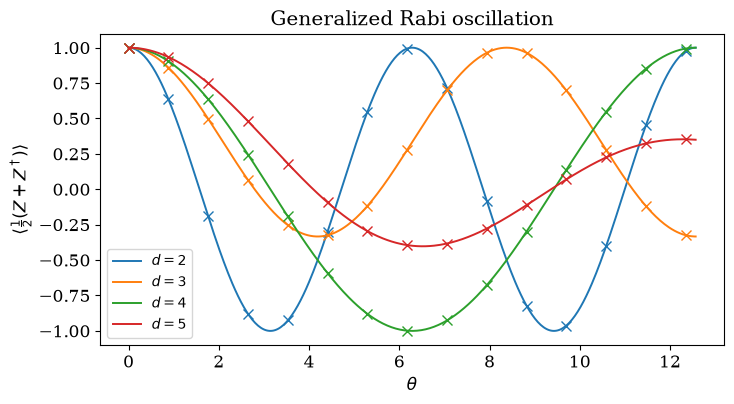

Max deviation 5.551e-16


In [10]:
def rabi_analytic(d, theta):
    k = np.arange(d)
    delta = np.cos(2 * np.pi * (k + 1) / d) - np.cos(2 * np.pi * k / d)
    return np.mean(np.cos(0.5 * theta * delta))


angles = np.linspace(0, 4 * np.pi, 400)
dims = (2, 3, 4, 5)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for i, d in enumerate(dims):
    exact = np.array([rabi_analytic(d, t) for t in angles])
    ax.plot(angles, exact, color=f"C{i}", lw=1.4, label=f"$d={d}$")
    sample = angles[::28]
    propagated = [
        WeylPropagator().expectation_value(
            clock_observable(1, d), [WeylRotation(single(1, d, 0, 1, 0), t)]
        ).expectation_value.real
        for t in sample
    ]
    ax.plot(sample, propagated, color=f"C{i}", ms=7, mfc="none", marker='x', linestyle='None')
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\langle \frac{1}{2}(Z + Z^\dagger)\rangle$")
ax.set_title("Generalized Rabi oscillation")
ax.legend(loc="lower left", fontsize=10)
plt.tight_layout()
plt.show()

worst = max(
    abs(
        WeylPropagator().expectation_value(
            clock_observable(1, d), [WeylRotation(single(1, d, 0, 1, 0), t)]
        ).expectation_value.real
        - rabi_analytic(d, t)
    )
    for d in (2, 3, 4, 5, 7, 8)
    for t in np.linspace(-6, 6, 61)
)
print(f"Max deviation {worst:.3e}")

## 5. Full clock model against exact dense simulation

The analytic case was one qudit. Here, we consider an interacting chain and a Trotterized evolution, and compare to a dense simulation of the full unitary.

In [11]:
def dense_reference(n, d, circuit, observable, fock):
    U = np.eye(d**n, dtype=complex)
    for rot in circuit:
        U = rot.dense_unitary() @ U
    O = sum(c * dense(k) for k, c in observable.items())
    psi = np.zeros(d**n, complex)
    psi[sum(f * d**k for k, f in enumerate(fock))] = 1.0
    return psi.conj() @ (U.conj().T @ O @ U) @ psi


print(f"{'d':>3} {'dim':>6} {'propagated':>18} {'dense reference':>18} {'|error|':>10} {'terms':>8}")
for d in (2, 3, 4, 5):
    n = 3
    circuit = clock_model_circuit(n, d, J=0.7, h=1.1, dt=0.15, steps=3)
    observable = clock_observable(n, d)
    result = WeylPropagator().expectation_value(observable, circuit, initial_state=0)
    want = dense_reference(n, d, circuit, observable, (0,) * n)
    got = result.expectation_value
    print(
        f"{d:>3} {d**n:>6} {got.real:>18.14f} {want.real:>18.14f} "
        f"{abs(got - want):>10.2e} {result.n_terms[-1]:>8}"
    )

  d    dim         propagated    dense reference    |error|    terms
  2      8   0.56168817721341   0.56168817721341   3.04e-17        6
  3     27   0.82445426735456   0.82445426735456   6.69e-16      486
  4     64   0.88084649254270   0.88084649254270   3.33e-16     2048
  5    125   0.91741070327982   0.91741070327982   2.00e-15     6250


## 6. d=2 Pauli propagation

Finally, as a sanity check, we run the Weyl propagator at $d = 2$ and compare to propaq's `PauliPropagator`.

In [12]:
from propaq.circuits import PauliCircuit
from propaq.circuits.pauli.rotation import PauliRotation
from propaq.datatypes import PauliString, PauliTermSum
from propaq.propagators import PauliPropagator

N_QUBITS, STEPS = 8, 6
circuit = clock_model_circuit(N_QUBITS, 2, J=0.7, h=1.1, dt=0.15, steps=STEPS)
observable = clock_observable(N_QUBITS, 2)


def as_pauli_string(key: WeylString) -> PauliString:
    x = sum(v << i for i, v in enumerate(key.a))
    z = sum(v << i for i, v in enumerate(key.b))
    return PauliString(x, z, key.n_units)


pauli_circuit = PauliCircuit([PauliRotation(as_pauli_string(r.generator), r.angle) for r in circuit])
pauli_observable = PauliTermSum({as_pauli_string(k): c.real for k, c in observable.items()})

weyl = WeylPropagator().expectation_value(observable, circuit, initial_state=0).expectation_value
pauli = PauliPropagator().expectation_value(pauli_observable, pauli_circuit).expectation_value

print(f"Weyl basis at d=2 :  {weyl.real:.15f}")
print(f"propaq PauliPropagator:  {pauli:.15f}")
print(f"difference            :  {abs(weyl.real - pauli):.2e}")

Weyl basis at d=2 :  -0.238407266428778
propaq PauliPropagator:  -0.238407266428779
difference            :  1.50e-15


## 7. Compare to dense simulators

We consider a system size that is difficult for a dense simulator to reach, and run the Weyl propagator.

In [13]:
N, D, STEPS = 30, 3, 6
circuit = clock_model_circuit(N, D, J=0.6, h=1.0, dt=0.1, steps=STEPS)
observable = clock_observable(N, D)
floor = CoefficientTruncator(1e-12)

print(f"n={N} qutrits, Hilbert dimension {D**N}, {len(circuit)} gates\n")
print(f"{'weight cutoff':>14} {'terms':>10} {'expectation':>18} {'|error|':>11} {'time':>8}")

rows = []
for cutoff in (2, 3, 4, 5, None):
    truncation = [floor] if cutoff is None else [WeightTruncator(cutoff), floor]
    start = time.perf_counter()
    result = WeylPropagator(truncation=truncation).expectation_value(observable, circuit)
    rows.append((cutoff, result.n_terms[-1], result.expectation_value.real, time.perf_counter() - start))

exact = rows[-1][2]
for cutoff, n_terms, value, elapsed in rows:
    label = "none (exact)" if cutoff is None else str(cutoff)
    error = "-" if cutoff is None else f"{abs(value - exact):.3e}"
    print(f"{label:>14} {n_terms:>10} {value:>18.14f} {error:>11} {elapsed:>7.2f}s")

n=30 qutrits, Hilbert dimension 205891132094649, 354 gates

 weight cutoff      terms        expectation     |error|     time
             2        100   0.74733415084440   2.115e-06    0.48s
             3        950   0.74733203579500   5.814e-11    2.78s
             4       3740   0.74733203585315   2.442e-15   10.73s
             5       9424   0.74733203585314   0.000e+00   13.86s
  none (exact)       9986   0.74733203585314           -   15.63s


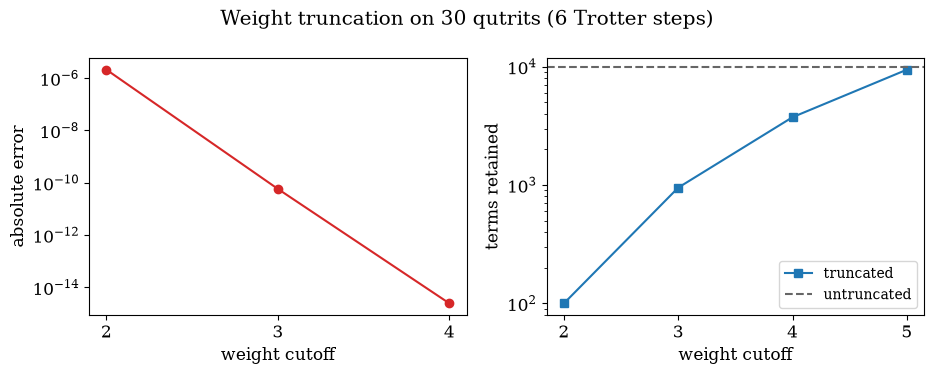

In [14]:
cutoffs = [r[0] for r in rows[:-1]]
resolved = [(r[0], abs(r[2] - exact)) for r in rows[:-1] if abs(r[2] - exact) > 0]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
axes[0].semilogy(*zip(*resolved), "o-", color="C3")
axes[0].set_xlabel("weight cutoff")
axes[0].set_ylabel("absolute error")
axes[0].set_xticks([c for c, _ in resolved])

axes[1].semilogy(cutoffs, [r[1] for r in rows[:-1]], "s-", color="C0", label="truncated")
axes[1].axhline(rows[-1][1], ls="--", color="0.4", label="untruncated")
axes[1].set_xlabel("weight cutoff")
axes[1].set_ylabel("terms retained")
axes[1].set_xticks(cutoffs)
axes[1].legend(fontsize=10)
fig.suptitle(f"Weight truncation on {N} qutrits ({STEPS} Trotter steps)")
plt.tight_layout()
plt.show()

We can get away with a weight cutoff of $4$ and still get a reasonably accurate value.
Noise composes the same way. propaq's `UniformNoiseModel` damps a weight-$w$ term by
$e^{-\gamma w}$, which is the Heisenberg action of the qudit depolarizing channel on
a Weyl string, so we can plug it in.

In [15]:
truncation = [WeightTruncator(4), CoefficientTruncator(1e-12)]
for gamma in (0.0, 1e-4, 5e-4, 2e-3):  # applied after every one of the 114 gates
    propagator = WeylPropagator(noise=UniformNoiseModel(gamma), truncation=truncation)
    value = propagator.expectation_value(observable, circuit).expectation_value
    print(f"gamma = {gamma:>4}:  <O> = {value.real:.12f}")

gamma =  0.0:  <O> = 0.747332035853
gamma = 0.0001:  <O> = 0.721368838797
gamma = 0.0005:  <O> = 0.626222779733
gamma = 0.002:  <O> = 0.368406273618


We can also run the same propagator through the zero-noise extrapolator without any changes.

In [ ]:
from propaq import ZeroNoiseExtrapolator

propagator = WeylPropagator(noise=UniformNoiseModel(0.001), truncation=truncation)
model = ZeroNoiseExtrapolator(lambda x, a, b: a*x + b, noise_values=[0.001, 0.002, 0.003, 0.004])

result = model.run(propagator, observable, circuit)

In [29]:
propagator.set_noise(None)
znv = propagator.expectation_value(observable, circuit).expectation_value

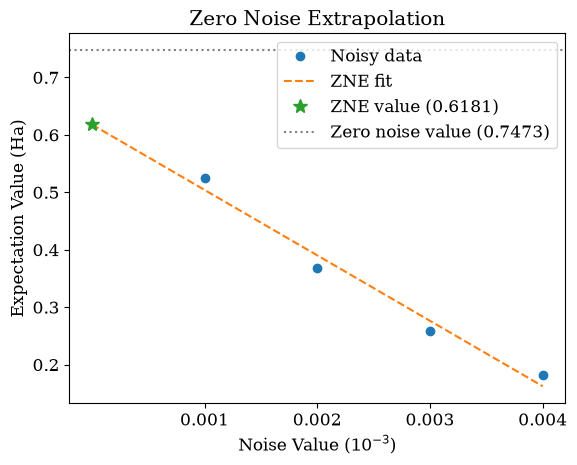

In [ ]:
plt.plot(result.noise_values, result.expectation_values, 'o', label='Noisy data')

noise_range = np.linspace(0, max(result.noise_values), 200)
fit_curve = [model.fitting_fn(x, *result.fit_params) for x in noise_range]
plt.plot(noise_range, fit_curve, '--', label='ZNE fit')
plt.plot(0, result.zero_noise_value, '*', markersize=10, label=f'ZNE value ({result.zero_noise_value:.4f})')
plt.axhline(znv, color='gray', linestyle=':', label=f'Zero noise value ({znv:.4f})')

plt.xticks([0.001, 0.002, 0.003, 0.004])
plt.xlabel('Noise Value ($10^{-3}$)')
plt.ylabel('Expectation Value (Ha)')
plt.title('Zero Noise Extrapolation')
plt.legend()
